In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [43]:
beer_info = pd.read_csv("Datasets/beer_info.csv")
beer_reviews = pd.read_csv("Datasets/beer_reviews.csv")
review_details = pd.read_csv("Datasets/review_details.csv")

In [44]:
beer_info.shape

(242921, 4)

In [45]:
beer_reviews.shape

(1654502, 4)

In [46]:
review_details.shape

(1654502, 5)

In [47]:
beer_info.describe()

,beer_abv
count,204526.000000
mean,6.558847
std,2.197321
min,0.010000
25%,5.000000
50%,6.000000
75%,7.800000
max,57.700000


In [48]:
beer_info.isna().sum()

beer_name           0
brewery_name       12
beer_style          0
beer_abv        38395
dtype: int64

In [49]:
merged = pd.merge(beer_reviews, beer_info, on = "beer_name", how = "left")

In [50]:
merged.isna().sum()

review_id                  0
beer_name                  0
reviewer_username        425
overall_score          98326
brewery_name          966336
beer_style            966334
beer_abv             1000301
dtype: int64

In [51]:
import seaborn as sns

<Axes: ylabel='beer_abv'>

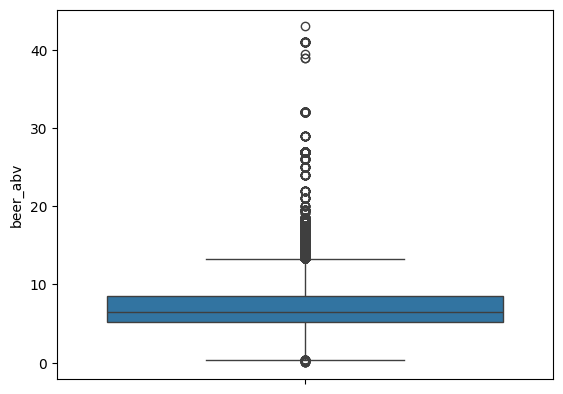

In [52]:
sns.boxplot(y = merged["beer_abv"])

In [53]:
import pandas as pd

col = merged["beer_abv"]

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = merged[(col < lower) | (col > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 12391


In [54]:
merged.head()


,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv
0,1,Sausa Weizen,stcules,1.5,NaN,NaN,NaN
1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2
2,3,BLACK HORSE BLACK BEER,stcules,3.0,NaN,NaN,NaN
3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0
4,5,Cauldron Dipa,johnmichaelsen,4.0,NaN,NaN,NaN


In [55]:
merged2= pd.merge(merged, review_details, on="review_id", how="left")

In [56]:
merged2.head()

,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv,aroma_score,appearance_score,taste_score,palate_score
0,1,Sausa Weizen,stcules,1.5,NaN,NaN,NaN,2.0,2.5,1.5,1.5
1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2,2.5,3.0,3.0,3.0
2,3,BLACK HORSE BLACK BEER,stcules,3.0,NaN,NaN,NaN,2.5,3.0,3.0,3.0
3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0,3.0,3.5,3.0,2.5
4,5,Cauldron Dipa,johnmichaelsen,4.0,NaN,NaN,NaN,4.5,4.0,4.5,4.0


In [57]:
merged2.isna().sum()

review_id                  0
beer_name                  0
reviewer_username        425
overall_score          98326
brewery_name          966336
beer_style            966334
beer_abv             1000301
aroma_score           145465
appearance_score           0
taste_score           135476
palate_score          231982
dtype: int64

In [58]:
df = merged2

In [59]:
df["brewery_name"] = df["brewery_name"].fillna("Unknown")

In [60]:
df.isna().sum()

review_id                  0
beer_name                  0
reviewer_username        425
overall_score          98326
brewery_name               0
beer_style            966334
beer_abv             1000301
aroma_score           145465
appearance_score           0
taste_score           135476
palate_score          231982
dtype: int64

In [61]:
df["beer_style"] = df["beer_style"].fillna(df["beer_style"].mode()[0])

<Axes: >

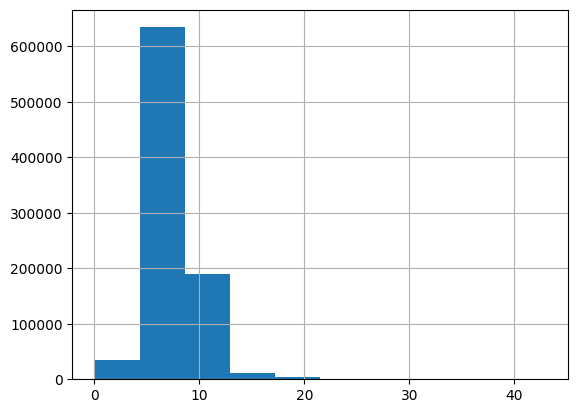

In [62]:
df["beer_abv"].hist()

In [63]:
df["beer_abv"] = df["beer_abv"].fillna(df["beer_abv"].median) 

<Axes: >

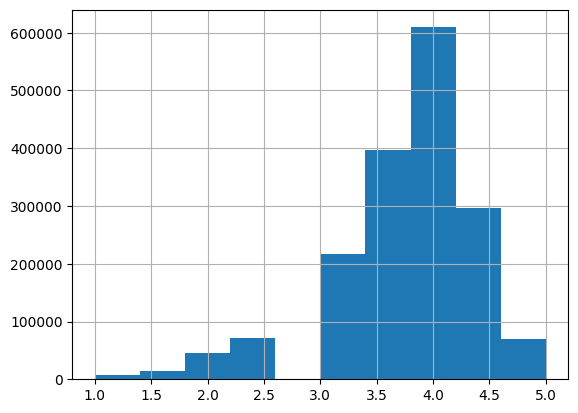

In [64]:
df["aroma_score"].hist()

In [65]:
df["aroma_score"] = df["aroma_score"].fillna(df["aroma_score"].median) 

In [66]:
df["aroma_score"] = pd.to_numeric(df["aroma_score"], errors="coerce")

In [67]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer()

cols = ["overall_score", "aroma_score", "taste_score", "palate_score", "appearance_score"]

df[cols] = imputer.fit_transform(df[cols])

In [68]:
df = df.dropna(subset=["reviewer_username"])

In [69]:
df.isna().sum()

review_id            0
beer_name            0
reviewer_username    0
overall_score        0
brewery_name         0
beer_style           0
beer_abv             0
aroma_score          0
appearance_score     0
taste_score          0
palate_score         0
dtype: int64

#
# To find the best consistent beer style  

In [70]:
df["beer_style"] = df["beer_style"].str.lower()

In [71]:
df["beer_style"] = df["beer_style"].str.lower()
df["beer_style"] = df["beer_style"].str.strip()
df["beer_style"] = df["beer_style"].str.replace(r"\s+", " ", regex=True)

In [72]:
df["beer_style"].nunique()

104

In [73]:
style_stats = df.groupby("beer_style")["overall_score"].agg(["mean","std","count"])
#--------------------------------------------------------------------
style_stats = style_stats[style_stats["count"] >= 1000]
best_styles = style_stats.sort_values(
    by=["mean","std"],
    ascending=[False, True]
)

print(best_styles.head(10))

                                      mean       std  count
beer_style                                                 
american wild ale                 4.108855  0.639589  10229
gueuze                            4.099912  0.612816   3407
quadrupel (quad)                  4.073513  0.619484  10583
american double / imperial stout  4.040302  0.654832  30374
keller bier / zwickel bier        4.039050  0.617981   1277
russian imperial stout            4.030233  0.626106  32222
weizenbock                        4.023062  0.583948   5555
eisbock                           4.008306  0.612844   1561
american double / imperial ipa    3.998030  0.634642  49267
rye beer                          3.988737  0.589601   5607


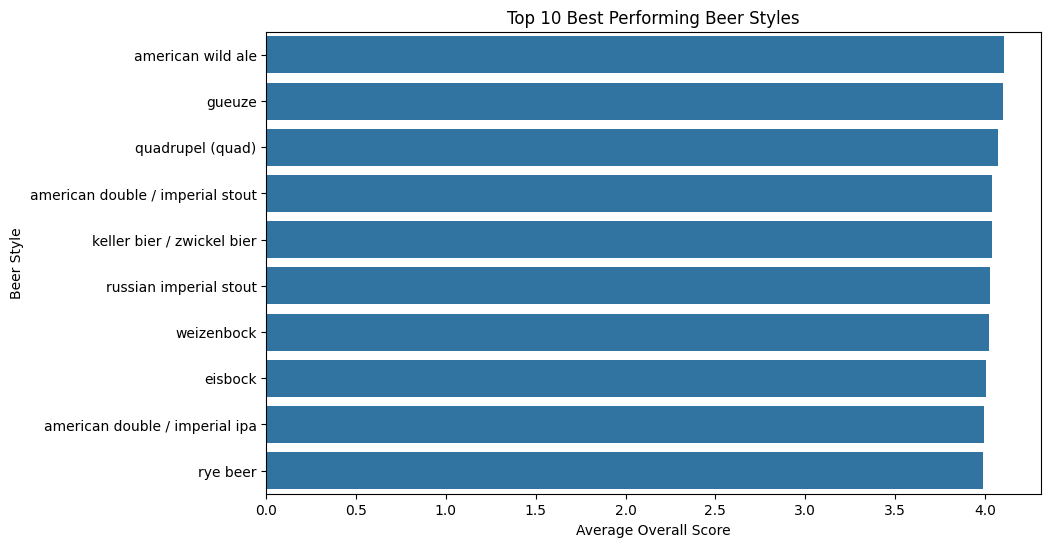

In [74]:
# get top 10 best styles
top10 = best_styles.head(10).reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="mean",
    y="beer_style"
)

plt.title("Top 10 Best Performing Beer Styles")
plt.xlabel("Average Overall Score")
plt.ylabel("Beer Style")

plt.show()

#
# To find underperforming styles

In [75]:
overall_mean = df["overall_score"].mean()
print(overall_mean)

3.818081469535075


In [76]:
style_stats["difference_from_avg"] = style_stats["mean"] - overall_mean

In [77]:
underperforming = style_stats[style_stats["difference_from_avg"] < 0]

In [78]:
underperforming = underperforming[underperforming["count"] >= 1000]

In [79]:
underperforming.sort_values("difference_from_avg").head(10)

,mean,std,count,difference_from_avg
beer_style,,,,
american malt liquor,2.660214,1.025181,2154,-1.157868
light lager,2.666448,1.033958,7833,-1.151634
euro strong lager,2.935897,0.904210,1361,-0.882184
american adjunct lager,2.999330,0.926870,17385,-0.818751
chile beer,3.055293,1.131397,1127,-0.762788
japanese rice lager,3.125931,0.788247,1070,-0.692151
euro pale lager,3.227389,0.800280,9681,-0.590692
euro dark lager,3.408678,0.739324,2609,-0.409403
american pale lager,3.411670,0.812324,5108,-0.406411


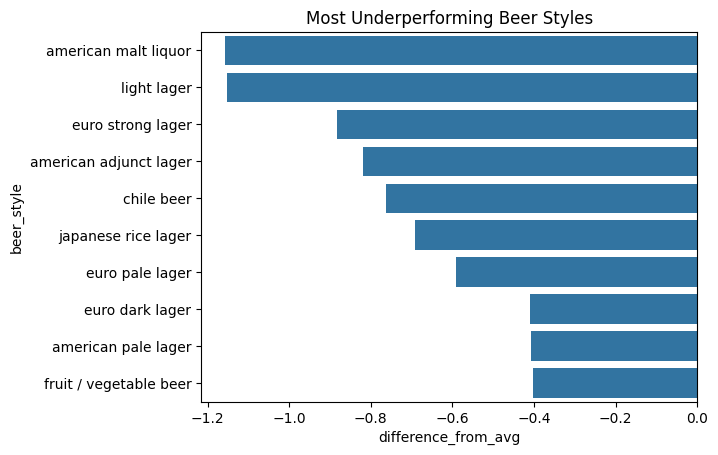

In [80]:
sns.barplot(
    data=underperforming.sort_values("difference_from_avg").head(10),
    x="difference_from_avg",
    y=underperforming.sort_values("difference_from_avg").head(10).index
)

plt.title("Most Underperforming Beer Styles")
plt.show()